<a href="https://colab.research.google.com/github/Mauricio-Fragoso-Mendoza/Simulacion-I/blob/main/TIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular.

Si la capacidad del camión es de 1 tonelada (1000 kg), ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

Solución: Se tiene la siguiente distribución:



La función $f(x)$ se define como:
$$f(x) = \cases{\frac{2(x-a)}{(b-a)(c-a)}&si $a \leq x < c$,\cr \frac{2}{b-a}&si $x=c$,\cr \frac{2(b-x)}{(b-a)(b-c)}&si $c \leq x \leq b$, \cr 0 &en otro caso}$$

Se tienen: $a=190$, $b=210$, $c=230$, por lo que la distribución queda como:
$$f(x) = \cases{0.0025x-0.475&si $190 \leq x < 210$,\cr 0.05&si $x=210$,\cr 0.575-0.0025x&si $210 < x \leq 230$, \cr 0 &en otro caso}$$

Se transformará la función $f(x)$ usando integración:
$$F(x)=\int_{-\infty}^{\infty} f(x)dx$$
$$F_1(x)=\int_{190}^{x} 0.0025x-0.475 dx = 0.0025x-0.475-[0.0025(190)-0.475] = 0.0025x-0.475-[0.475-0.475] = 0.0025x-0.475-[0] = 0.0025x-0.475$$
$$F_2(x)=\int_{210}^{x} 0.575-0.0025x dx = 0.575-0.0025x-[0.575-0.0025(210)] = 0.575-0.0025x-[0.575-0.525] = 0.575-0.0025x-0.05 = 0.525-0.0025x$$

Teniendo como resultado:
$$F(x)=\cases{0&si x < 190,\cr 0.0025x-0.475&si $190 \leq x < 210$,\cr 0.05&si $x=210$,\cr 0.525-0.0025x&si $210 < x \leq 230$, \cr 1&si x > 230}$$

Por último, se tendrán números aleatorios para los resultados de las dos integrales evaluadas usando $F(x)=U$.

Para $190 \leq X < 210$
$$0.0025X-0.475=U ⇒ 0.0025X=U+0.475 ⇒ X=400U+190$$


Para $210 < X \leq 230$
$$0.525-0.0025X=U ⇒ 0.0025X=0.525-U ⇒ X=210-400U$$

Al final,
$$X=\cases{400U+190&si $0 \leq x < 0.05$,\cr 210-400U&si $0.05 \leq x < 1$}$$

Por último, se graficarán las funciones estimadas.

In [1]:
import random as r
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def tibasa(n):
    l = []
    for i in range(n):
        u = r.random()
        if 0 <= u < 0.05:
            x = 400*u+190
            l.append(x)
        else:
            x = 210-400*u
            l.append(x)
    return l

In [3]:
U=tibasa(10000)

(array([183., 229., 186., 206., 230., 193., 205., 222., 190., 202., 193.,
        191., 231., 183., 199., 188., 215., 196., 238., 184., 200., 181.,
        192., 193., 182., 214., 215., 211., 198., 169., 205., 188., 213.,
        194., 194., 195., 185., 207., 209., 195., 189., 214., 195., 191.,
        191., 190., 238., 203., 207., 178.]),
 array([-189.99798519, -181.99808712, -173.99818906, -165.99829099,
        -157.99839293, -149.99849486, -141.99859679, -133.99869873,
        -125.99880066, -117.99890259, -109.99900453, -101.99910646,
         -93.99920839,  -85.99931033,  -77.99941226,  -69.99951419,
         -61.99961613,  -53.99971806,  -45.99982   ,  -37.99992193,
         -30.00002386,  -22.0001258 ,  -14.00022773,   -6.00032966,
           1.9995684 ,    9.99946647,   17.99936454,   25.9992626 ,
          33.99916067,   41.99905874,   49.9989568 ,   57.99885487,
          65.99875293,   73.998651  ,   81.99854907,   89.99844713,
          97.9983452 ,  105.99824327,  113.998

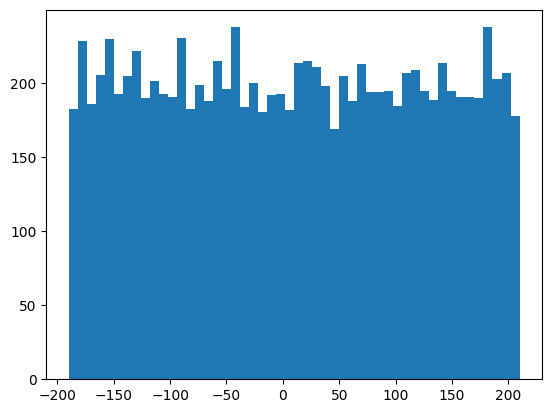

In [5]:
plt.hist(U, bins=50)

In [6]:
def fda(U):
    n=len(U)
    x=np.sort(U)
    y=np.arange(0,n)/n
    return x,y

In [7]:
x_math,y_math=fda(U)

In [8]:
media = np.mean(U)

In [11]:
m=print(media)

9.050753500403301


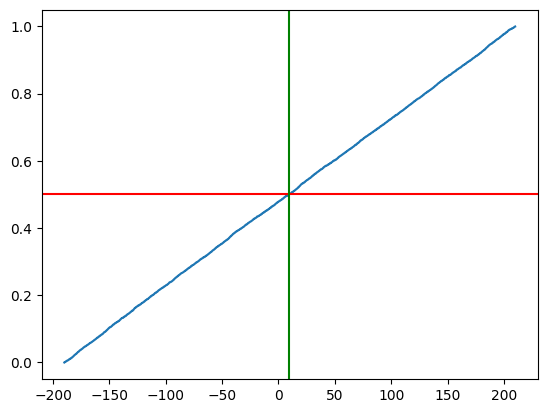

In [9]:
plt.step(x_math,y_math)
plt.axhline(y=0.5, color='red') #La mediana
plt.axvline(x=media, color='green') # La media

In [17]:
p=1/media
s=5*p
e=1-s

In [20]:
print('Por lo tanto, la probabilidad de que las tinas excedan la capacidad del camión es del ',e*100,'%')

Por lo tanto, la probabilidad de que las tinas excedan la capacidad del camión es del  44.75598081665576 %
